In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use("ggplot")

In [9]:
DATA_PATH = "../project/data/processed"

nav = pd.read_csv(
    f"{DATA_PATH}/02_nav_history_clean.csv"
)

fund = pd.read_csv(
    f"{DATA_PATH}/01_fund_master_clean.csv"
)

benchmark = pd.read_csv(
    f"{DATA_PATH}/10_benchmark_indices_clean.csv"
)

In [10]:
DATA_PATH = "../project/data/processed"

nav = pd.read_csv(
    f"{DATA_PATH}/02_nav_history_clean.csv"
)

fund = pd.read_csv(
    f"{DATA_PATH}/01_fund_master_clean.csv"
)

benchmark = pd.read_csv(
    f"{DATA_PATH}/10_benchmark_indices_clean.csv"
)

In [11]:
# Pivot NAV data

nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)


# Daily Returns

daily_returns = (
    nav_pivot
    .pct_change()
)


daily_returns.describe()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
count,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,...,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000,1149.000000
mean,0.000142,0.000170,0.001080,0.000852,0.000424,0.000242,0.000674,0.000110,0.000645,0.000865,...,0.001082,0.000256,0.000710,0.000477,0.001074,0.000825,0.001124,0.000522,0.001055,0.001194
std,0.009164,0.002460,0.011929,0.009177,0.016251,0.000319,0.008086,0.011424,0.009927,0.008913,...,0.010008,0.000323,0.009241,0.011561,0.008941,0.009719,0.011134,0.009042,0.011179,0.015648
min,-0.024744,-0.008188,-0.044238,-0.038121,-0.051847,-0.000766,-0.021104,-0.036695,-0.031271,-0.028490,...,-0.029748,-0.000704,-0.031505,-0.045218,-0.029451,-0.026127,-0.031266,-0.036676,-0.030092,-0.048870
25%,-0.006282,-0.001445,-0.006654,-0.005733,-0.010799,0.000020,-0.004931,-0.008096,-0.006277,-0.005285,...,-0.005857,0.000021,-0.005546,-0.007360,-0.004796,-0.006056,-0.006533,-0.005441,-0.006437,-0.008741
50%,-0.000070,0.000099,0.001086,0.000808,0.000182,0.000249,0.000632,0.000472,0.000390,0.000969,...,0.001081,0.000258,0.000431,0.000753,0.001289,0.000914,0.000727,0.000432,0.001239,0.000987
75%,0.006523,0.001824,0.008844,0.007165,0.011286,0.000456,0.006076,0.008108,0.007177,0.007152,...,0.007745,0.000482,0.006995,0.008171,0.007100,0.007207,0.008984,0.006639,0.008945,0.011440
max,0.032145,0.008837,0.041954,0.033956,0.054851,0.001247,0.025565,0.040745,0.032386,0.028218,...,0.033554,0.001254,0.028407,0.036193,0.030025,0.031415,0.039176,0.029362,0.041995,0.048490


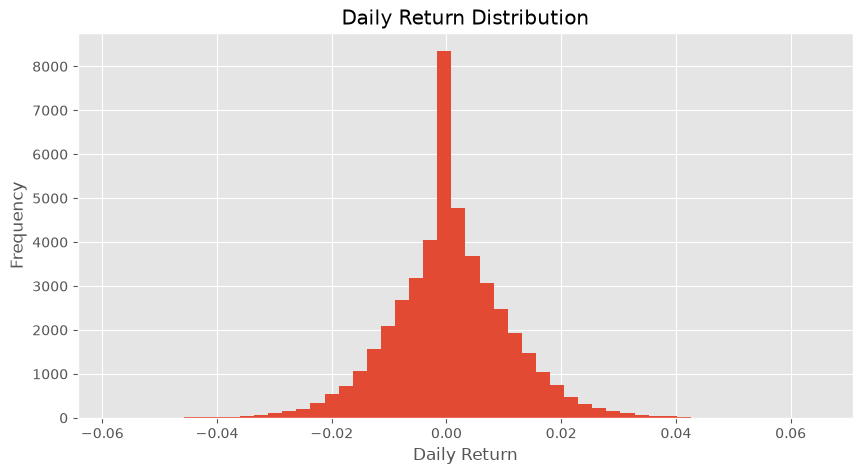

In [12]:
plt.figure(figsize=(10,5))

daily_returns.stack().hist(
    bins=50
)

plt.title(
    "Daily Return Distribution"
)

plt.xlabel(
    "Daily Return"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [15]:
# Fix nav_pivot date index

nav_pivot.index = pd.to_datetime(nav_pivot.index)

print(nav_pivot.index.dtype)

datetime64[us]


In [16]:
# CAGR Calculation (1Y, 3Y, 5Y)

def calculate_cagr(data, years):

    days_required = 252 * years

    end_nav = data.iloc[-1]

    if len(data) >= days_required:
        start_nav = data.iloc[-days_required]

    else:
        start_nav = data.iloc[0]

        years = (
            (data.index[-1] - data.index[0]).days
            / 365
        )

    return (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )


cagr_table = pd.DataFrame(
    {
        "CAGR_1Y": calculate_cagr(nav_pivot, 1),
        "CAGR_3Y": calculate_cagr(nav_pivot, 3),
        "CAGR_5Y": calculate_cagr(nav_pivot, 5)
    }
)

cagr_table.head()

,CAGR_1Y,CAGR_3Y,CAGR_5Y
amfi_code,,,
100016,-0.033055,-0.000316,0.026352
100025,0.025018,0.046143,0.044551
100033,0.477346,0.336292,0.300997
101206,0.450939,0.325286,0.235205
101207,-0.242421,-0.026965,0.079331


In [18]:
# Annual Return and Volatility

risk_free_rate = 0.065   # RBI repo rate proxy (6.5%)

annual_return = (
    daily_returns.mean()
    * 252
)

annual_volatility = (
    daily_returns.std()
    * np.sqrt(252)
)

# Sharpe Ratio

sharpe_ratio = (
    (annual_return - risk_free_rate)
    /
    annual_volatility
)

sharpe_ratio.sort_values(
    ascending=False
).head()

amfi_code
148567    1.448291
120843    1.306744
148569    1.234930
119551    1.208267
120505    1.180101
dtype: float64

In [19]:
# Sortino Ratio

downside_returns = daily_returns.copy()

downside_returns[
    downside_returns > 0
] = 0


downside_std = (
    downside_returns.std()
    * np.sqrt(252)
)


sortino_ratio = (
    (annual_return - risk_free_rate)
    /
    downside_std
)


sortino_ratio.sort_values(
    ascending=False
).head()

amfi_code
148567    2.609850
120843    2.463887
148569    2.278106
119551    2.243325
120505    2.158384
dtype: float64

In [20]:
# Alpha and Beta Calculation

nifty100 = benchmark[
    benchmark["index_name"] == "Nifty 100"
].copy()

nifty100 = nifty100.sort_values("date")


nifty100_returns = (
    nifty100["close_value"]
    .pct_change()
    .dropna()
)


alpha_beta_list = []


for code in daily_returns.columns:

    fund_returns = (
        daily_returns[code]
        .dropna()
    )

    length = min(
        len(fund_returns),
        len(nifty100_returns)
    )

    slope, intercept, r, p, se = stats.linregress(
        nifty100_returns.iloc[:length],
        fund_returns.iloc[:length]
    )

    alpha_beta_list.append(
        {
            "amfi_code": code,
            "Alpha": intercept * 252,
            "Beta": slope
        }
    )


alpha_beta = pd.DataFrame(
    alpha_beta_list
)


alpha_beta.head()

C:\Users\admin\AppData\Local\Temp\ipykernel_8736\620444107.py:32: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r, p, se = stats.linregress(


,amfi_code,Alpha,Beta
0,100016,NaN,NaN
1,100025,NaN,NaN
2,100033,NaN,NaN
3,101206,NaN,NaN
4,101207,NaN,NaN


In [21]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [22]:
# Maximum Drawdown

running_max = nav_pivot.cummax()

drawdown = (
    nav_pivot / running_max
) - 1


max_drawdown = drawdown.min()


# Worst drawdown dates

worst_dates = drawdown.idxmin()


drawdown_report = pd.DataFrame(
    {
        "amfi_code": max_drawdown.index,
        "max_drawdown": max_drawdown.values,
        "worst_drawdown_date": worst_dates.values
    }
)


drawdown_report.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown,worst_drawdown_date
22,119599,-0.525742,2025-10-28
17,119095,-0.516778,2026-05-11
4,101207,-0.354469,2026-05-11
39,149324,-0.311719,2025-01-03
21,119598,-0.287060,2025-05-14


In [25]:
# Load performance dataset

performance = pd.read_csv(
    "../project/data/processed/07_scheme_performance_clean.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [27]:
# Fund Scorecard

scorecard = pd.DataFrame()

scorecard["amfi_code"] = cagr_table.index


scorecard["return_rank"] = (
    cagr_table["CAGR_3Y"]
    .rank(pct=True)
)


scorecard["sharpe_rank"] = (
    sharpe_ratio
    .rank(pct=True)
    .values
)


scorecard["alpha_rank"] = (
    alpha_beta
    .set_index("amfi_code")
    ["Alpha"]
    .rank(pct=True)
    .values
)


expense = performance.set_index(
    "amfi_code"
)["expense_ratio_pct"]


scorecard["expense_rank"] = (
    expense
    .rank(
        pct=True,
        ascending=False
    )
    .values
)


scorecard["drawdown_rank"] = (
    max_drawdown
    .rank(
        pct=True
    )
    .values
)


scorecard["final_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["drawdown_rank"] * 10
)


scorecard.sort_values(
    "final_score",
    ascending=False
).head()

,amfi_code,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,final_score
0,100016,NaN,0.150,NaN,0.2625,0.175,NaN
1,100025,NaN,0.050,NaN,0.9250,0.925,NaN
2,100033,NaN,0.850,NaN,0.5000,0.525,NaN
3,101206,NaN,0.800,NaN,0.8875,0.800,NaN
4,101207,NaN,0.325,NaN,0.8000,0.075,NaN


In [28]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [29]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved
